# General setup

In [ ]:
import pandas as pd
import gc
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import date

from google.colab import userdata

from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.utils import to_categorical

print("Default GPU Device:", tf.test.gpu_device_name() if tf.test.gpu_device_name() else "No GPU available")


Default GPU Device: No GPU available


# Environment setup

In [ ]:
# Retrieve secrets from the Colab "Secrets" tab
try:
    KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY = userdata.get('KAGGLE_KEY')
except userdata.SecretNotFoundError as e:
    print(f"Error: {e}")
    print("Make sure you've added these keys in the Secrets tab (the key icon on the left).")

In [ ]:
# Google Drive setup

from google.colab import drive
drive.mount('/content/drive')
files_base = '/content/drive/MyDrive/AI ML Certificate with Berkeley Haas/capstone/lendingclub'

Mounted at /content/drive


# Fetching Datasets

## Kaggle setup
This section does general setup for Kaggle that will be used for the LendingClub dataset as well as the S&P 500 dataset.

In [ ]:
!pip install kaggle

In [ ]:
# Get Kaggle username and API token, and make them available to the API
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

download_path = os.path.join(files_base, 'kaggle')

## Fetching the LendingClub dataset from Kaggle
This section pertains specifically to the LendingClub dataset.

In [ ]:
skip_download_lendingclub = False
if not skip_download_lendingclub:
  from kaggle.api.kaggle_api_extended import KaggleApi
  dataset = 'wordsforthewise/lending-club'

  # Initialize API
  api = KaggleApi()
  api.authenticate()
  print('Authenticated to Kaggle')

  # Download dataset
  print(f'Downloading dataset {dataset} to {download_path}')
  api.dataset_download_files(dataset, path=download_path, unzip=True)
  print('Downloaded files')

In [ ]:
# File paths (note subtle case differences)
accepted_filename = os.path.join(
    'accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv')
rejected_filename = os.path.join(
    'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv')
# gzipped input files are extracted into subfolders
accepted_path = os.path.join(download_path, accepted_filename)
rejected_path = os.path.join(download_path, rejected_filename)

In [ ]:
# Load into Pandas. Unlike the EDA version of this, read _only_ the columns
# that we intend to keep.
retained_columns = ['grade', 'sub_grade', 'issue_d', 'loan_status', 'loan_amnt']
accepted_df = pd.read_csv(accepted_path, usecols=retained_columns)

# We won't be using the rejected loans to make decsions, because they lack
# actual performance data. However, to access this loan data, uncomment the
# lines below.
#rejected_df = pd.read_csv(rejected_path, low_memory=True)
#print("Rejected shape:", rejected_df.shape)

## Fetching the Federal Funds Effective rate dataset from the St. Louis Fed
The FEDFUNDS dataset is [available from the St. Louis Fed](https://fred.stlouisfed.org/series/FEDFUNDS). It is a simple dataset, providing a date and the percentage rate.

In [ ]:
# Fetch a dataset from 2005-Jan through 2020-Jan,
# overlapping with the LendingClub dataset.
url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?bgcolor=%23ebf3fb&chart_type=line&drp=0&fo=open%20sans&graph_bgcolor=%23ffffff&height=450&mode=fred&recession_bars=on&txtcolor=%23444444&ts=12&tts=12&width=1320&nt=0&thu=0&trc=0&show_legend=yes&show_axis_titles=yes&show_tooltip=yes&id=FEDFUNDS&scale=left&cosd=2005-01-01&coed=2020-01-01&line_color=%230073e6&link_values=false&line_style=solid&mark_type=none&mw=3&lw=3&ost=-99999&oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&fgst=lin&fgsnd=2020-02-01&line_index=1&transformation=lin&vintage_date=2026-02-22&revision_date=2026-02-22&nd=1954-07-01'
fed_funds_df = pd.read_csv(url, parse_dates=['observation_date'])

## Fetching the S&P 500 dataset from Kaggle

In [ ]:
skip_download_sp500 = False
if not skip_download_sp500:
  from kaggle.api.kaggle_api_extended import KaggleApi
  dataset = 'henryhan117/sp-500-historical-data'

  # Initialize API
  api = KaggleApi()
  api.authenticate()
  print('Authenticated to Kaggle')

  # Download dataset
  print(f'Downloading dataset {dataset} to {download_path}')
  api.dataset_download_files(dataset, path=download_path, unzip=True)
  print('Downloaded files')

Authenticated to Kaggle
Dataset URL: https://www.kaggle.com/datasets/henryhan117/sp-500-historical-data
Downloaded files


In [ ]:
sp500_filename = 'SPX.csv'
sp500_path = os.path.join(download_path, sp500_filename)

sp500_df = pd.read_csv(sp500_path, parse_dates=["Date"])
print("S&P 500 shape: ", sp500_df.shape)

S&P 500 shape:  (23323, 7)


# Processing the data

A complete analysis of the input datasets can be found in the notebook `lendingclub_eda.ipynb`.

Here we retain only the portion of code from that analysis necessary for the final overall analysis. It is intentionally minimalistic; for grading purposes, please review the EDA notebook for a more complete description of the same code.

## LendingClub

In [ ]:
# Don't truncate these columns, even though there's a lot of them.
pd.set_option('display.max_rows', 500)       # show all rows
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', 80)            # let it use full console width

In [ ]:
# Figure out how many NaNs we have to deal with, since we only want to retain
# columns with >20% valid data.
nans_percentage = accepted_df.isna().mean() * 100
mostly_valid_columns = nans_percentage[nans_percentage > 20]

In [ ]:
# Drop columns that are 20%+ NaN. The data is too messy to use; and, as it turns
# out, these columns weren't useful anyway since they generally pertain to
# information only known during the duration of the loan, so they can't be used
# at lending decision time.
nan_columns_to_drop = accepted_df.columns[nans_percentage > 20]
print(nan_columns_to_drop)
accepted_df.drop(columns=nan_columns_to_drop, inplace=True)

# Now, drop rows that have a NaN anywhre in them
row_has_nan = accepted_df.isna().any(axis=1)
percent_rows_with_nan = row_has_nan.mean() * 100

Index([], dtype='object')


In [ ]:
accepted_df = accepted_df.copy()[['grade', 'sub_grade', 'issue_d', 'loan_status', 'loan_amnt']].dropna()

In [ ]:
letter_order = ['A', 'B', 'C', 'D', 'E', 'F']
letter_rank = {letter: i for i, letter in enumerate(letter_order)}

letters = accepted_df['sub_grade'].str[0]
numbers = accepted_df['sub_grade'].str[1].astype(int)
numbers = numbers.astype(int)

accepted_df['grade_score'] = (
    (5 - letters.map(letter_rank)) * 5 + (6 - numbers)
)

In [ ]:
# Standardize a function to convert datetime to a numerical index; we'll use the
# same system for this and for economic data. (We assume all years are leap
# years and all months have 31 days.)
def datetime_to_index(dt):
  return dt.year*366 + dt.month*31 + dt.day

accepted_df['issue_d_dt'] = pd.to_datetime(
    accepted_df['issue_d'], format='%b-%Y')
accepted_df['issue_d_month_index'] = datetime_to_index(
    accepted_df['issue_d_dt'].dt)

In [ ]:
# Let's ignore those very few non-compliant loans; not sure how to make heads or tails of those.
accepted_df = accepted_df[~accepted_df['loan_status'].isin([
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'])
]

In [ ]:
loan_status_mapping = {
    "Fully Paid":         2,
    "Current":            2,

    "In Grace Period":    1,
    "Late (16-30 days)":  1,
    "Late (31-120 days)": 1,

    "Charged Off":        1,
    "Default" :           1
}

accepted_df['loan_status_code'] = accepted_df['loan_status'].dropna().map(loan_status_mapping).astype(int)

## Fed Funds Effective Rate

In [ ]:
fed_funds_df['date_index'] = datetime_to_index(
    fed_funds_df['observation_date'].dt)

In [ ]:
fed_funds_df['dFEDFUNDS'] = fed_funds_df['FEDFUNDS'].diff()

## S&P 500

In [ ]:
sp500_df['date_index'] = datetime_to_index(
    sp500_df['Date'].dt)

In [ ]:
yrs_to_average = 1
sp500_df['avg_close'] = sp500_df['Close'].rolling(yrs_to_average * 5*52).mean()
sp500_df['close_above_avg'] = sp500_df['Close'] - sp500_df['avg_close']

# Data Modeling

From here, we'll start with making some predictions. Below is setup that is common to all models.

In [ ]:
# For training speed, use only a subset of the data.
# When using _all_ data for training, set data_frac = 1.0.
data_frac = 0.5

test_size = 0.5
epochs = 30
verbosity = 1

tf.random.set_seed(67)

# For an apples-to-apples comparison, we'll use the same architecture
# everywhere.
def make_model():
  model = Sequential([
      # A node for each input value in the largest model, plus bias.
      # Set regularization terms less than the default due to few inputs.
      Dense(8, activation='relu'),
      # One hidden layer for better reasoning about multiple inputs.
      Dense(10, activation='relu'),
      # One node for each output value
      Dense(3, activation='softmax')
  ])
  model.compile(optimizer='adamax', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

def make_early_stop():
  return tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    min_delta=0.0001,
    restore_best_weights=True
  )

In [ ]:
# Previous experimentation yielded unexpected results when adopting a
# chronological train/test split. Further digging revealed that later loans
# had a bias toward being current--likely because they hadn't had time to lead
# to default yet. Therefore, we will drop the trailing 3 years of data.
oldest_loan_allowed_index = datetime_to_index(date(2014, 12, 31))

accepted_df = accepted_df[accepted_df['issue_d_month_index'] <= oldest_loan_allowed_index]

## LendingClub modeling by grade

At a base level, we'll assume that LendingClub has done a pretty good job of choosing borrower grades as a function of all available data; from here, we can try to predict loan outcomes as a function of that initial grade. We'll do that with a neural net.

To start with, let's simply try to predict loan status codes (which describe the final loan outcome) with borrower grade.

Epoch 1/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.8303 - loss: 0.4677 - val_accuracy: 0.8344 - val_loss: 0.4238
Epoch 2/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8331 - loss: 0.4256 - val_accuracy: 0.8344 - val_loss: 0.4233
Epoch 3/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8331 - loss: 0.4254 - val_accuracy: 0.8344 - val_loss: 0.4233
Epoch 4/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8331 - loss: 0.4253 - val_accuracy: 0.8344 - val_loss: 0.4233
Epoch 5/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8331 - loss: 0.4253 - val_accuracy: 0.8344 - val_loss: 0.4233
Epoch 6/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8331 - loss: 0.4253 - val_accuracy: 0.8344 - val_loss: 0.4232
Epoch 7/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8331 - loss: 0.4253 - val_accuracy: 0.8344 - val_loss: 0.4232
Epoch 8/30
3870/3870 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8331 - loss: 0

Text(0.5, 0, 'Epoch')

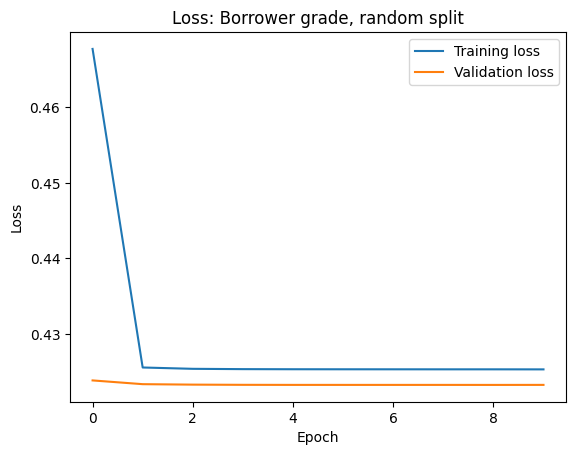

In [ ]:
df2 = accepted_df[['grade_score', 'loan_status_code']].dropna()
df2 = df2.sample(frac=data_frac)

t = make_column_transformer((StandardScaler(), ['grade_score']),
                            remainder='passthrough').set_output(transform="pandas")
df2_scaled = t.fit_transform(df2)

X = df2_scaled[['standardscaler__grade_score']]
y = to_categorical(df2_scaled['remainder__loan_status_code'].astype(int))

(X_train, X_test, y_train, y_test) = train_test_split(X, y, test_size=test_size)

model = make_model()
history2 = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
    callbacks=[make_early_stop()], verbose=verbosity)

# Plot the results over time
plt.plot(history2.history['loss'], label="Training loss")
plt.plot(history2.history['val_loss'], label="Validation loss")
plt.legend()

plt.title('Loss: Borrower grade, random split')
plt.ylabel('Loss')
plt.xlabel('Epoch')

That's a great start—but wait! We've used the standard `train_test_split` function to divide the data. Since data will tend to have trends over time, this may be a bit too generous to the testing model; that is, we may be experiencing data leakage.

So instead, let's split based on a dividing line in time. We'll train before that time, and test afterward. This is much more like realistic data as it would be used for actual loan decisions: Train a model based on the best data up to a date, then launch that model and see how it performs over time—_without_ the benefit of being able to "see the future."

Here we'll redo the analysis.

Epoch 1/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8391 - loss: 0.4523 - val_accuracy: 0.8205 - val_loss: 0.4430
Epoch 2/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8465 - loss: 0.4077 - val_accuracy: 0.8205 - val_loss: 0.4428
Epoch 3/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8465 - loss: 0.4076 - val_accuracy: 0.8205 - val_loss: 0.4428
Epoch 4/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8465 - loss: 0.4076 - val_accuracy: 0.8205 - val_loss: 0.4428
Epoch 5/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8465 - loss: 0.4076 - val_accuracy: 0.8205 - val_loss: 0.4428
Epoch 6/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8465 - loss: 0.4076 - val_accuracy: 0.8205 - val_loss: 0.4428
Epoch 7/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8465 - loss: 0.4076 - val_accuracy: 0.8205 - val_loss: 0.4428
Epoch 8/30
4026/4026 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8465 - loss: 0

Text(0.5, 0, 'Epoch')

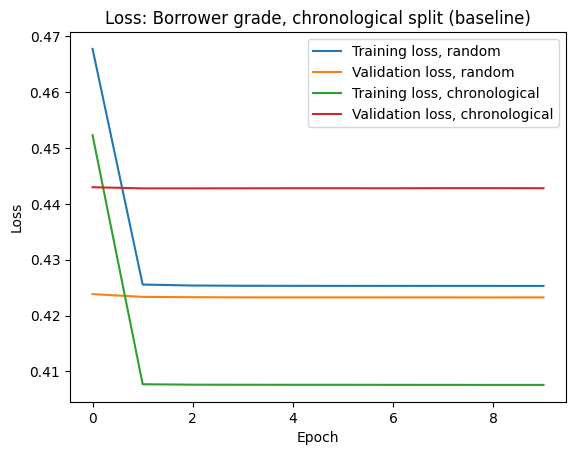

In [ ]:
df2 = accepted_df[['grade_score', 'loan_status_code', 'issue_d_month_index']].dropna()
df2 = df2.sample(frac=data_frac)

t = make_column_transformer((StandardScaler(), ['grade_score']),
                            remainder='passthrough').set_output(transform="pandas")
df2_scaled = t.fit_transform(df2)

# Split based on time
cutoff_index = df2['issue_d_month_index'].quantile(1 - test_size)

df2_scaled_train = df2_scaled[df2['issue_d_month_index'] <= cutoff_index]
df2_scaled_test = df2_scaled[df2['issue_d_month_index'] > cutoff_index]

# Define X and y for train/test sets
X_train = df2_scaled_train[['standardscaler__grade_score']]
X_test = df2_scaled_test[['standardscaler__grade_score']]
y_train = to_categorical(df2_scaled_train['remainder__loan_status_code'].astype(int))
y_test = to_categorical(df2_scaled_test['remainder__loan_status_code'].astype(int))

# Train the model
model = make_model()
history2_random = history2
history2 = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
    callbacks=[make_early_stop()], verbose=verbosity)

# Plot the results over time
plt.plot(history2_random.history['loss'], label="Training loss, random")
plt.plot(history2_random.history['val_loss'], label="Validation loss, random")
plt.plot(history2.history['loss'], label="Training loss, chronological")
plt.plot(history2.history['val_loss'], label="Validation loss, chronological")
plt.legend()

plt.title('Loss: Borrower grade, chronological split (baseline)')
plt.ylabel('Loss')
plt.xlabel('Epoch')

Aha, it looks like this one definitely performed worse… so there _is_ an unfair advantage to the random data splitting of `train_test_split`; therefore, for the remainder of this analysis, we'll rely on the fairer and more realistic time-based splitting.

We're off to a good start. Let's see if we can perform better by also considering the loan amount.

Epoch 1/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8415 - loss: 0.4353 - val_accuracy: 0.8216 - val_loss: 0.4406
Epoch 2/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8448 - loss: 0.4096 - val_accuracy: 0.8216 - val_loss: 0.4403
Epoch 3/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8448 - loss: 0.4094 - val_accuracy: 0.8216 - val_loss: 0.4402
Epoch 4/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8448 - loss: 0.4093 - val_accuracy: 0.8216 - val_loss: 0.4402
Epoch 5/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8448 - loss: 0.4092 - val_accuracy: 0.8216 - val_loss: 0.4401
Epoch 6/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8448 - loss: 0.4092 - val_accuracy: 0.8216 - val_loss: 0.4400
Epoch 7/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8448 - loss: 0.4091 - val_accuracy: 0.8216 - val_loss: 0.4400
Epoch 8/30
4020/4020 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8448 - loss: 0

Text(0.5, 0, 'Epoch')

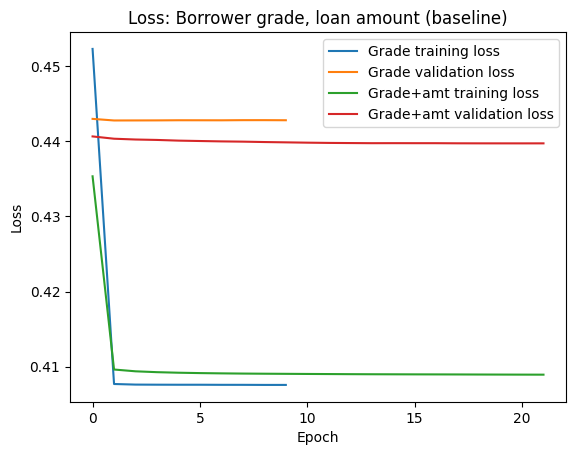

In [ ]:
df3 = accepted_df[['grade_score', 'loan_amnt', 'loan_status_code', 'issue_d_month_index']].dropna()

df3 = df3.sample(frac=data_frac)

t = make_column_transformer((StandardScaler(), ['grade_score', 'loan_amnt']),
                            remainder='passthrough').set_output(transform="pandas")
df3_scaled = t.fit_transform(df3)

## Define X and y, split based on time. Reuse cutoff_index from above.
df3_scaled_train = df3_scaled[df3['issue_d_month_index'] <= cutoff_index]
df3_scaled_test = df3_scaled[df3['issue_d_month_index'] > cutoff_index]
X_train = df3_scaled_train[['standardscaler__grade_score', 'standardscaler__loan_amnt']]
X_test = df3_scaled_test[['standardscaler__grade_score', 'standardscaler__loan_amnt']]
y_train = to_categorical(df3_scaled_train['remainder__loan_status_code'].astype(int))
y_test = to_categorical(df3_scaled_test['remainder__loan_status_code'].astype(int))

# Train the model
model = make_model()
history3 = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
    callbacks=[make_early_stop()], verbose=verbosity)

# Plot the results over time
plt.plot(history2.history['loss'], label="Grade training loss")
plt.plot(history2.history['val_loss'], label="Grade validation loss")
plt.plot(history3.history['loss'], label="Grade+amt training loss")
plt.plot(history3.history['val_loss'], label="Grade+amt validation loss")
plt.legend()

plt.title('Loss: Borrower grade, loan amount (baseline)')
plt.ylabel('Loss')
plt.xlabel('Epoch')

Validation loss is about the same, but slightly better, when factoring in the loan amount. Loan issuers will certainly be considering loan amounts in addition to general borrower grades, and this shows that loan amounts do factor in to the actual outcome. Also, since validation loss continues to drop as training continues, this suggests that we are not yet overfitting.

Let's explore the hypothesis that this actually correlates with economic conditions. To do this, let's take a measure of stock market performance (_without_ the federal funds rate), and see how that compares with the best analysis from above, incorporating information about both borrower grade and loan amount, but _not_ time.

Text(0.5, 0, 'Epoch')

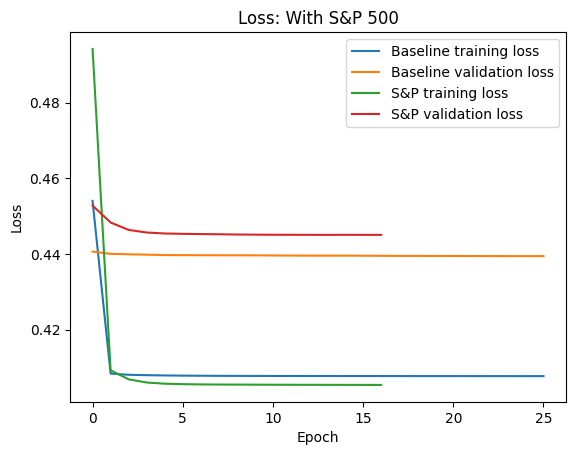

In [ ]:
df5 = accepted_df.rename(columns={'issue_d_month_index':'date_index'})

# Merge in S&P 500 columns
df5 = df5.merge(
    sp500_df[['date_index', 'Close', 'avg_close', 'close_above_avg']],
    on='date_index',
    how='left'
).dropna()

df5 = df5.sample(frac=data_frac)

t = make_column_transformer((StandardScaler(), ['grade_score', 'loan_amnt', 'close_above_avg']),
                            remainder='passthrough').set_output(transform="pandas")
df5_scaled = t.fit_transform(df5)

## Define X and y, split based on time. Reuse cutoff_index from above.
df5_scaled_train = df5_scaled[df5['date_index'] <= cutoff_index]
df5_scaled_test = df5_scaled[df5['date_index'] > cutoff_index]
X_train = df5_scaled_train[['standardscaler__grade_score', 'standardscaler__loan_amnt', 'standardscaler__close_above_avg']]
X_test = df5_scaled_test[['standardscaler__grade_score', 'standardscaler__loan_amnt', 'standardscaler__close_above_avg']]
y_train = to_categorical(df5_scaled_train['remainder__loan_status_code'].astype(int))
y_test = to_categorical(df5_scaled_test['remainder__loan_status_code'].astype(int))

# Train the model
model = make_model()
history5 = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
    callbacks=[make_early_stop()], verbose=verbosity)

# Plot the results over time, for both history3 (the best above) and history 5 (with the S&P 500)
plt.plot(history3.history['loss'], label='Baseline training loss')
plt.plot(history3.history['val_loss'], label='Baseline validation loss')
plt.plot(history5.history['loss'], label='S&P training loss')
plt.plot(history5.history['val_loss'], label='S&P validation loss')
plt.legend()

plt.title('Loss: With S&P 500')
plt.ylabel('Loss')
plt.xlabel('Epoch')

It appears that factoring in the S&P 500 data (specifically, the amount by which the current closing price exceeds the 1-year moving average) actually degrades performance slightly. Perhaps the stock market isn't the best indicator of stock market performance. We'll still consider this against other measures.

Let's see if performance improves with _only_ the federal funds rate instead of the S&P 500. And finally, let's see if it improves if we include _both_.

In [ ]:
df6 = accepted_df.rename(columns={'issue_d_month_index':'date_index'})

# Merge in federal funds rate data
df6 = df6.merge(
    fed_funds_df[['date_index', 'FEDFUNDS', 'dFEDFUNDS']],
    on='date_index',
    how='left'
).dropna()

df6 = df6.sample(frac=data_frac)

t = make_column_transformer((StandardScaler(), ['grade_score', 'loan_amnt', 'FEDFUNDS', 'dFEDFUNDS']),
                            remainder='passthrough').set_output(transform="pandas")
df6_scaled = t.fit_transform(df6)

# Split data based on time cutoffs
df6_scaled_train = df6_scaled[df6['date_index'] <= cutoff_index]
df6_scaled_test = df6_scaled[df6['date_index'] > cutoff_index]
X_train = df6_scaled_train[['standardscaler__grade_score', 'standardscaler__loan_amnt', 'standardscaler__FEDFUNDS', 'standardscaler__dFEDFUNDS']]
X_test = df6_scaled_test[['standardscaler__grade_score', 'standardscaler__loan_amnt', 'standardscaler__FEDFUNDS', 'standardscaler__dFEDFUNDS']]
y_train = to_categorical(df6_scaled_train['remainder__loan_status_code'].astype(int))
y_test = to_categorical(df6_scaled_test['remainder__loan_status_code'].astype(int))

# Train the model
model = make_model()
history6 = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
    callbacks=[make_early_stop()], verbose=verbosity)



In [ ]:
df7 = accepted_df.rename(columns={'issue_d_month_index':'date_index'})

# Merge in S&P 500 columns
df7 = df7.merge(
    sp500_df[['date_index', 'close_above_avg']],
    on='date_index',
    how='left'
).dropna()

# Merge in federal funds rate data
df7 = df7.merge(
    fed_funds_df[['date_index', 'FEDFUNDS', 'dFEDFUNDS']],
    on='date_index',
    how='left'
)

df7 = df7.sample(frac=data_frac)

t = make_column_transformer((StandardScaler(), ['grade_score', 'loan_amnt', 'FEDFUNDS', 'dFEDFUNDS', 'close_above_avg']),
                            remainder='passthrough').set_output(transform="pandas")
df7_scaled = t.fit_transform(df7)

# Split the data based on time cutoffs
df7_scaled_train = df7_scaled[df7['date_index'] <= cutoff_index]
df7_scaled_test = df7_scaled[df7['date_index'] > cutoff_index]
X_train = df7_scaled_train[['standardscaler__grade_score', 'standardscaler__loan_amnt', 'standardscaler__FEDFUNDS', 'standardscaler__dFEDFUNDS', 'standardscaler__close_above_avg']]
X_test = df7_scaled_test[['standardscaler__grade_score', 'standardscaler__loan_amnt', 'standardscaler__FEDFUNDS', 'standardscaler__dFEDFUNDS', 'standardscaler__close_above_avg']]
y_train = to_categorical(df7_scaled_train['remainder__loan_status_code'].astype(int))
y_test = to_categorical(df7_scaled_test['remainder__loan_status_code'].astype(int))

# Train the model
model = make_model()
history7 = model.fit(
    X_train, y_train, epochs=epochs, validation_data=(X_test, y_test),
    callbacks=[make_early_stop()], verbose=verbosity)



Epoch 1/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8432 - loss: 0.4635 - val_accuracy: 0.8216 - val_loss: 0.4413
Epoch 2/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8464 - loss: 0.4096 - val_accuracy: 0.8216 - val_loss: 0.4401
Epoch 3/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.8464 - loss: 0.4080 - val_accuracy: 0.8216 - val_loss: 0.4400
Epoch 4/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8464 - loss: 0.4076 - val_accuracy: 0.8216 - val_loss: 0.4399
Epoch 5/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8464 - loss: 0.4074 - val_accuracy: 0.8216 - val_loss: 0.4398
Epoch 6/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8464 - loss: 0.4072 - val_accuracy: 0.8216 - val_loss: 0.4398
Epoch 7/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8464 - loss: 0.4071 - val_accuracy: 0.8216 - val_loss: 0.4398
Epoch 8/30
2674/2674 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8464 - loss: 0

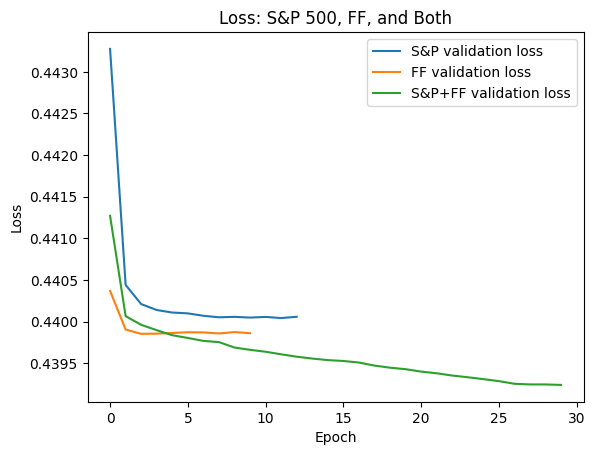

In [ ]:
# Plot the results over time -- for S&P 500 only, fed funds only, and both combined
plt.plot(history5.history['val_loss'], label='S&P validation loss')
plt.plot(history6.history['val_loss'], label='FF validation loss')
plt.plot(history7.history['val_loss'], label='S&P+FF validation loss')
plt.legend()

plt.title('Loss: S&P 500, FF, and Both')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Finally we've found our best model: incorporating _both_ the S&P 500 _and_ the Fed data. We already established above that using _only_ the S&P 500 data, performance was worse than baseline. This suggests that layering the Fed data in with the S&P 500 provides additional context necessary to interpret the latter.

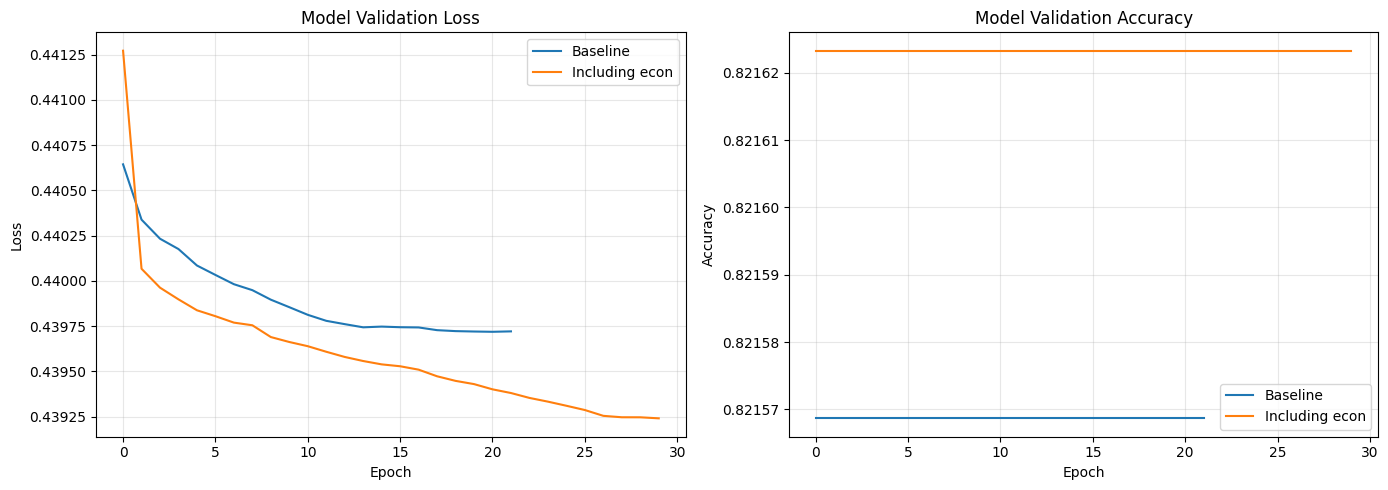

In [ ]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Validation Loss ---
ax1.plot(history3.history['val_loss'], label='Baseline')
ax1.plot(history7.history['val_loss'], label='Including econ')
ax1.set_title('Model Validation Loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Validation Accuracy ---
ax2.plot(history3.history['val_accuracy'], label='Baseline')
ax2.plot(history7.history['val_accuracy'], label='Including econ')
ax2.set_title('Model Validation Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

Here we can clearly see that the combined model outperforms the baseline. However, the improvement in accuracy is modest—large enough to matter for a large loan portfolio, but in absolute terms not that big. However, it provides some indication that evaluating additional macroeconomic benchmarks might be a worthwhile activity.